Olá, Victor

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
- Aplicou scaler
- Bons gráficos
- Boas análises e conclusões

Gabaritou o projeto. Parabéns pela dedicação.
</div>






# Projeto de Predição de Rotatividade de Clientes (Churn) — Model Fitness

## 📖 Contexto do Negócio
A rede de academias Model Fitness está desenvolvendo uma estratégia orientada por dados para melhorar a interação com seus clientes e reduzir a rotatividade (churn). A perda de clientes é um dos principais desafios enfrentados por academias e serviços baseados em assinatura, pois impacta diretamente a receita e o crescimento sustentável do negócio.

Nem sempre é evidente quando um cliente abandona a academia. Muitos usuários não cancelam formalmente, apenas deixam de frequentar. Para este projeto, consideramos churn quando um cliente deixa de comparecer por um período prolongado.

A Model Fitness digitalizou parte dos perfis e histórico de comportamento de seus clientes para prever a rotatividade e criar estratégias de retenção.

---

## 🎯 Objetivos do Projeto

Os principais objetivos deste projeto são:

1. Desenvolver um modelo preditivo capaz de estimar a probabilidade de churn de cada cliente no próximo mês.
2. Identificar os fatores mais relevantes que influenciam a saída dos clientes.
3. Segmentar os clientes em grupos com características e comportamentos semelhantes.
4. Construir perfis de usuários típicos.
5. Elaborar recomendações estratégicas para retenção e melhoria da experiência do cliente.

---

## 🧰 Ferramentas Utilizadas

As seguintes ferramentas serão utilizadas:

- **Python**
- **Bibliotecas de análise de dados**
  - Pandas
  - NumPy
- **Visualização**
  - Matplotlib
  - Seaborn
- **Machine Learning**
  - Scikit-learn
- **Clusterização**
  - K-means e métodos relacionados

O desenvolvimento será realizado em ambiente de notebook (Jupyter ou Google Colab).

---

## 📊 Conjunto de Dados

O dataset fornecido pela Model Fitness contém informações sobre clientes em um determinado mês e seu comportamento no mês anterior.

### 🔹 Variável alvo
- **Churn** — indica se o cliente abandonou a academia no mês analisado.

### 🔹 Dados demográficos e perfil
- **gender** — gênero do cliente
- **age** — idade
- **Near_Location** — se o cliente mora ou trabalha próximo à academia
- **Phone** — se o cliente forneceu telefone

### 🔹 Relacionamento com a academia
- **Partner** — funcionário de empresa parceira
- **Promo_friends** — inscrição por indicação ("traga um amigo")
- **Lifetime** — tempo (em meses) desde a primeira matrícula

### 🔹 Informações de contrato
- **Contract_period** — duração do contrato (1, 3, 6 ou 12 meses)
- **Month_to_end_contract** — meses restantes do contrato

### 🔹 Comportamento e engajamento
- **Group_visits** — participação em aulas coletivas
- **Avg_class_frequency_total** — frequência média semanal ao longo do histórico
- **Avg_class_frequency_current_month** — frequência média semanal no mês atual

### 🔹 Consumo adicional
- **Avg_additional_charges_total** — gasto total com serviços extras (café, produtos, massagem, etc.)

### 🔹 Caminho do arquivo
O conjunto de dados está disponível em:

`/datasets/gym_churn_us.csv`

---

## 📌 Metodologia Geral

O projeto será dividido nas seguintes etapas:

1. Importação e preparação dos dados  
2. Análise exploratória  
3. Modelagem preditiva  
4. Segmentação de clientes  
5. Interpretação  
6. Recomendações estratégicas  

Cada etapa será documentada de forma clara e orientada à tomada de decisão.

---

## 🔹 Etapa 1 — Importação e Preparação Inicial dos Dados

Nesta etapa, realizaremos a configuração do ambiente de análise, incluindo a importação das bibliotecas necessárias para manipulação, visualização e modelagem de dados.

Em seguida, será feita a leitura do conjunto de dados fornecido pela Model Fitness, armazenando-o em um DataFrame para permitir a exploração inicial.

Os principais objetivos desta etapa são:

- Importar as bibliotecas essenciais para o projeto.
- Carregar o dataset.
- Realizar uma inspeção inicial da estrutura dos dados.
- Verificar possíveis problemas como:
  - valores ausentes
  - tipos de dados incorretos
  - duplicatas
- Preparar o conjunto de dados para as próximas análises.

Essa etapa é fundamental para garantir a qualidade e confiabilidade das análises posteriores.

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning e clusterização (serão usados mais adiante)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Leitura do dataset
gym_churn = pd.read_csv('/datasets/gym_churn_us.csv')

# Visualização inicial
gym_churn.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Informações gerais
gym_churn.info()

# Estatísticas descritivas
gym_churn.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


## 🔹 Etapa 2 — Análise Exploratória dos Dados (AED)

Nesta etapa, realizaremos uma análise exploratória do conjunto de dados com o objetivo de compreender melhor sua estrutura, identificar padrões iniciais e comparar o comportamento entre clientes que permaneceram e aqueles que cancelaram.

Os principais objetivos desta etapa são:

- Verificar a presença de valores ausentes.
- Analisar estatísticas descritivas (média, desvio padrão, mínimos e máximos).
- Comparar as médias das variáveis entre clientes que ficaram e clientes que saíram.
- Visualizar distribuições das variáveis para ambos os grupos.
- Construir e analisar a matriz de correlação.

Essa etapa é fundamental para gerar hipóteses e orientar as etapas de modelagem preditiva.

In [4]:
gym_churn.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [5]:
churn_grouped = gym_churn.groupby('Churn').mean()
churn_grouped

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


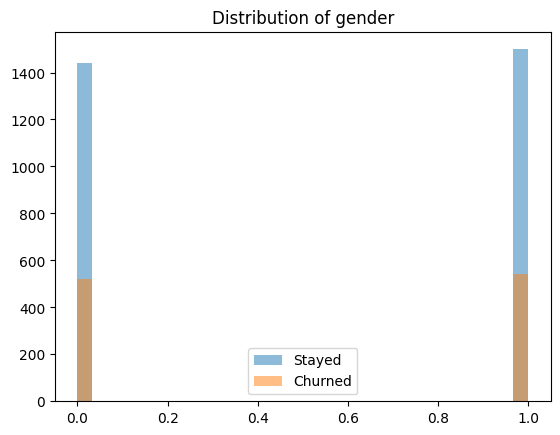

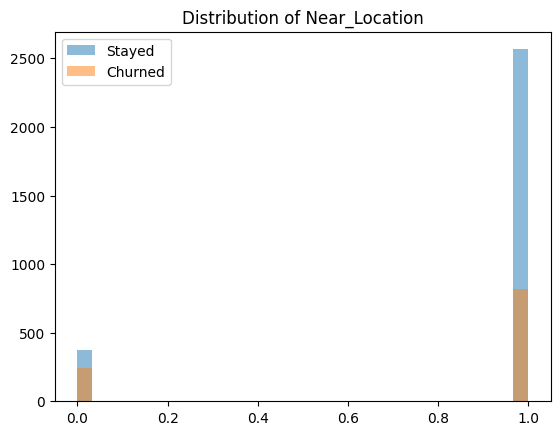

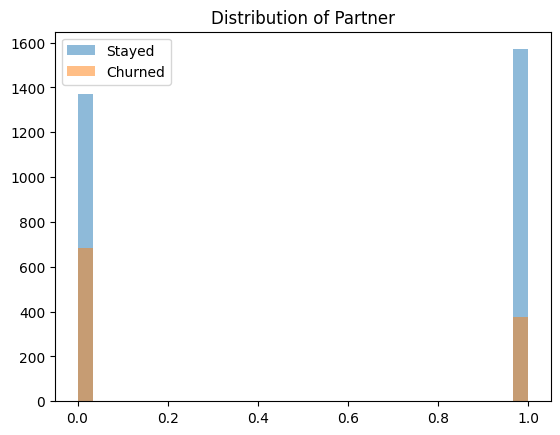

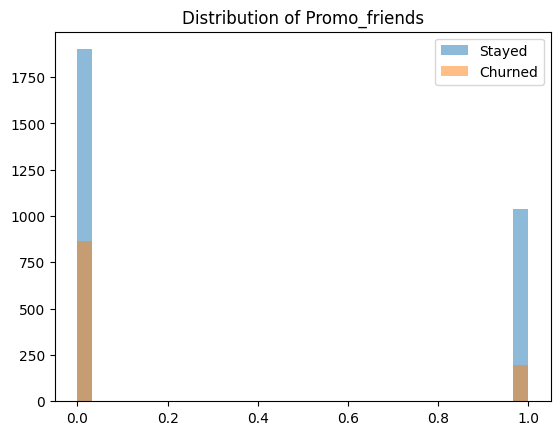

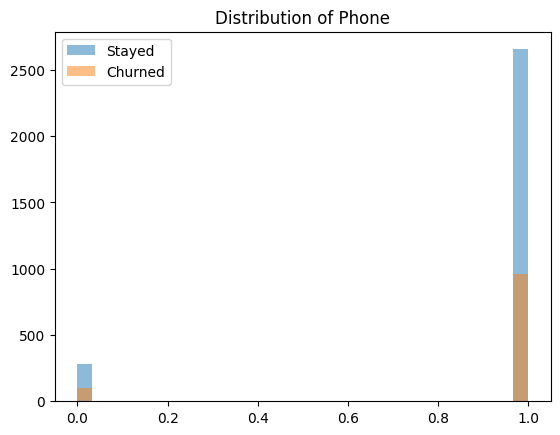

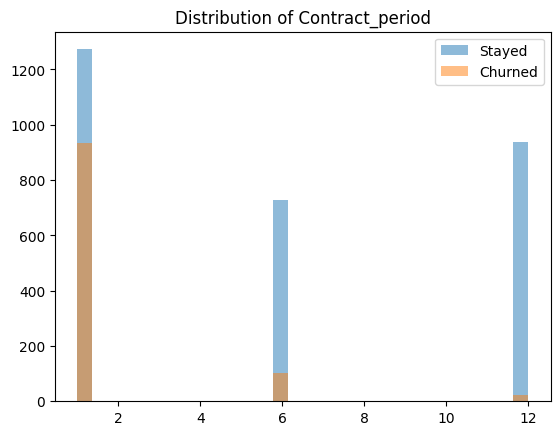

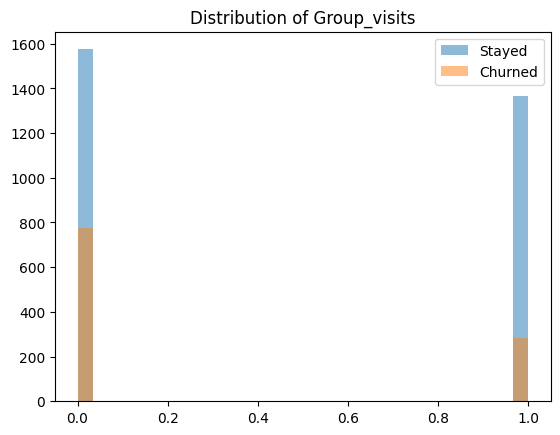

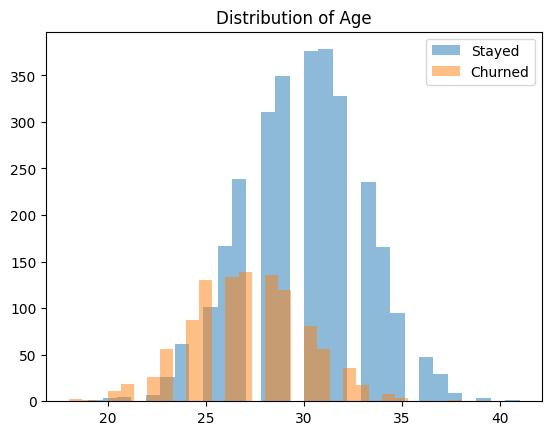

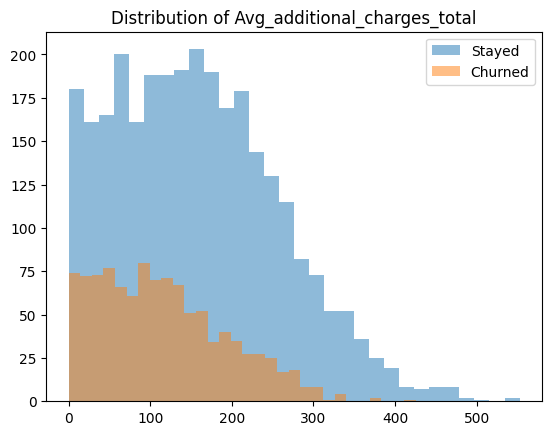

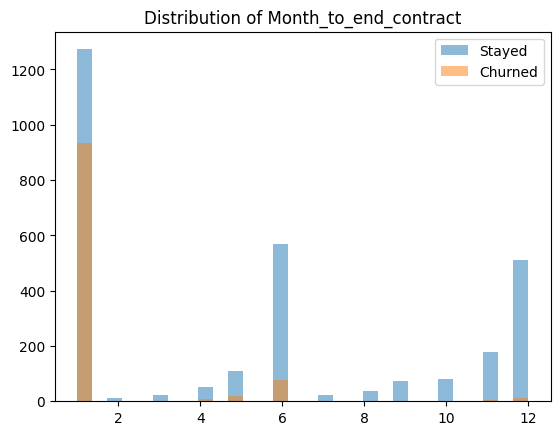

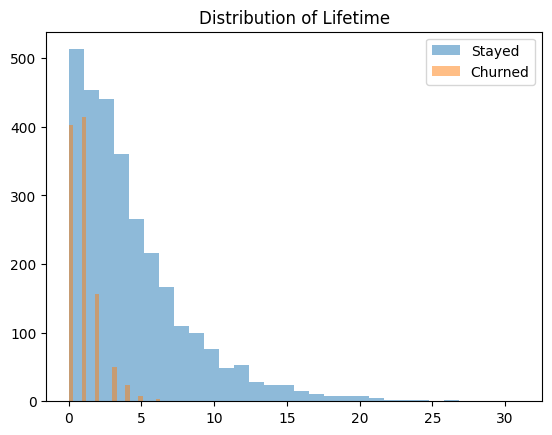

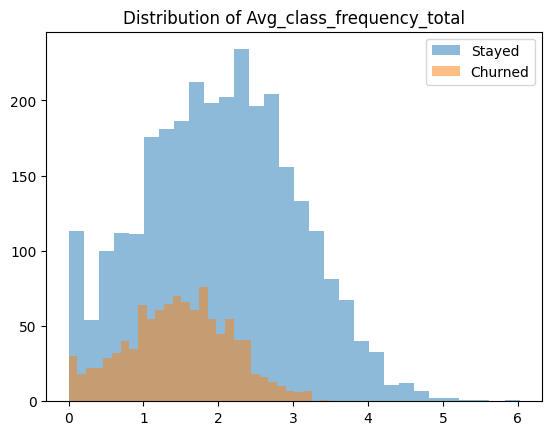

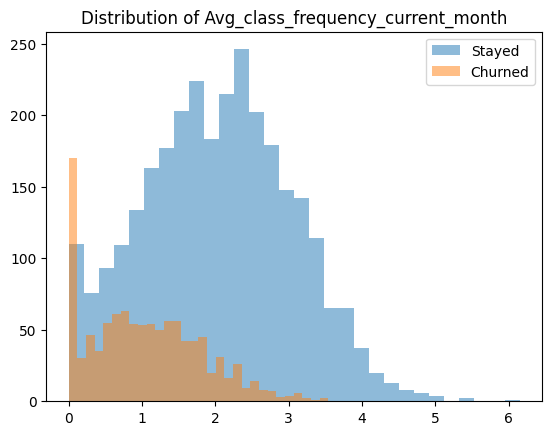

In [6]:
churned = gym_churn[gym_churn['Churn'] == 1]
stayed = gym_churn[gym_churn['Churn'] == 0]

features = gym_churn.columns.drop('Churn')

for col in features:
    plt.figure()
    plt.hist(stayed[col], bins=30, alpha=0.5, label='Stayed')
    plt.hist(churned[col], bins=30, alpha=0.5, label='Churned')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

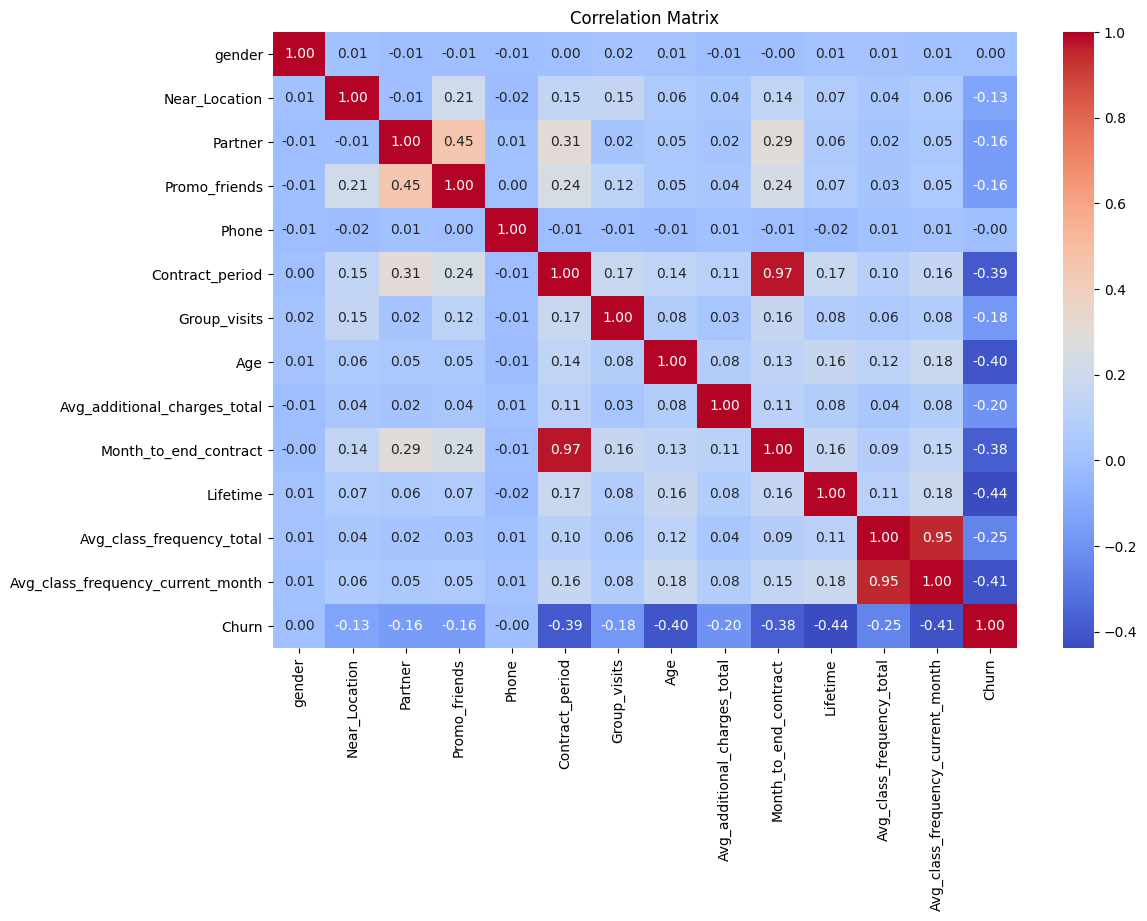

In [7]:
corr_matrix = gym_churn.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Insights

Partindo da análise destas variáveis e possível levantar algumas hipóteses, nada definitivo, mas uma interpretação inicial:
 - As variáveis 'Gender' e 'Phone' não apresentam forte relação com churn
 - As variáveis 'Near_Location', 'Partner', 'Promo_friends' e 'Group_visits' apresentam uma correlação moderada
 - As variáveis com a correlação mais forte são:
   * 'Contrac_period'
   * 'Month_to_end_contract'
   * 'Lifetime'
   * 'Frequency'
   * 'Age'

## 🔹 Etapa 3 — Modelagem Preditiva de Churn

Nesta etapa, construiremos modelos de classificação binária para prever a probabilidade de rotatividade (churn) dos clientes no próximo mês.

A variável alvo será **Churn**, onde:
- 1 = cliente saiu
- 0 = cliente permaneceu

Os dados serão divididos em conjuntos de treino e validação utilizando `train_test_split()`.

Serão treinados dois modelos distintos:

- Regressão Logística
- Floresta Aleatória (Random Forest)

Os modelos serão avaliados utilizando as seguintes métricas:

- Acurácia
- Precisão
- Sensibilidade (Recall)

O objetivo é comparar o desempenho dos modelos e identificar qual apresenta melhor capacidade preditiva.

In [8]:
X = gym_churn.drop('Churn', axis=1)
y = gym_churn['Churn']

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [11]:
#Modelo 1 - Regressão Logística
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_val_scaled)

print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_val, y_pred_log))
print("Precision:", precision_score(y_val, y_pred_log))
print("Recall:", recall_score(y_val, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_val, log_model.predict_proba(X_val_scaled)[:, 1]))

Logistic Regression Metrics:
Accuracy: 0.91625
Precision: 0.8729281767955801
Recall: 0.7821782178217822
ROC-AUC: 0.9693781251034803


In [12]:
#Modelo 2 - Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1]))

Random Forest Metrics:
Accuracy: 0.91
Precision: 0.8494623655913979
Recall: 0.7821782178217822
ROC-AUC: 0.9613025265737276


## Avaliação dos Modelos

A Regressão Logística apresentou desempenho superior em praticamente todas as métricas avaliadas:

- Maior acurácia, indicando melhor desempenho geral de classificação.
- Maior precisão, demonstrando maior confiabilidade ao prever churn.
- Sensibilidade idêntica à da Floresta Aleatória.
- ROC-AUC ligeiramente superior, indicando melhor capacidade de separação entre as classes.

## 🔹 Etapa 4 — Agrupamento de Clientes (Clusterização)

Nesta etapa, aplicaremos técnicas de aprendizado não supervisionado para identificar agrupamentos (clusters) de clientes com características semelhantes.

Os objetivos são:

- Padronizar os dados para garantir comparabilidade entre variáveis.
- Construir um dendrograma utilizando o método hierárquico para estimar o número ideal de agrupamentos.
- Aplicar o algoritmo K-means com n=5 clusters.
- Analisar as médias das características em cada grupo.
- Examinar distribuições das variáveis por cluster.
- Calcular a taxa de rotatividade (churn) por agrupamento.

Essa análise permitirá identificar perfis típicos de clientes e entender quais grupos apresentam maior risco de saída.

In [13]:
X_cluster = gym_churn.drop('Churn', axis=1)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

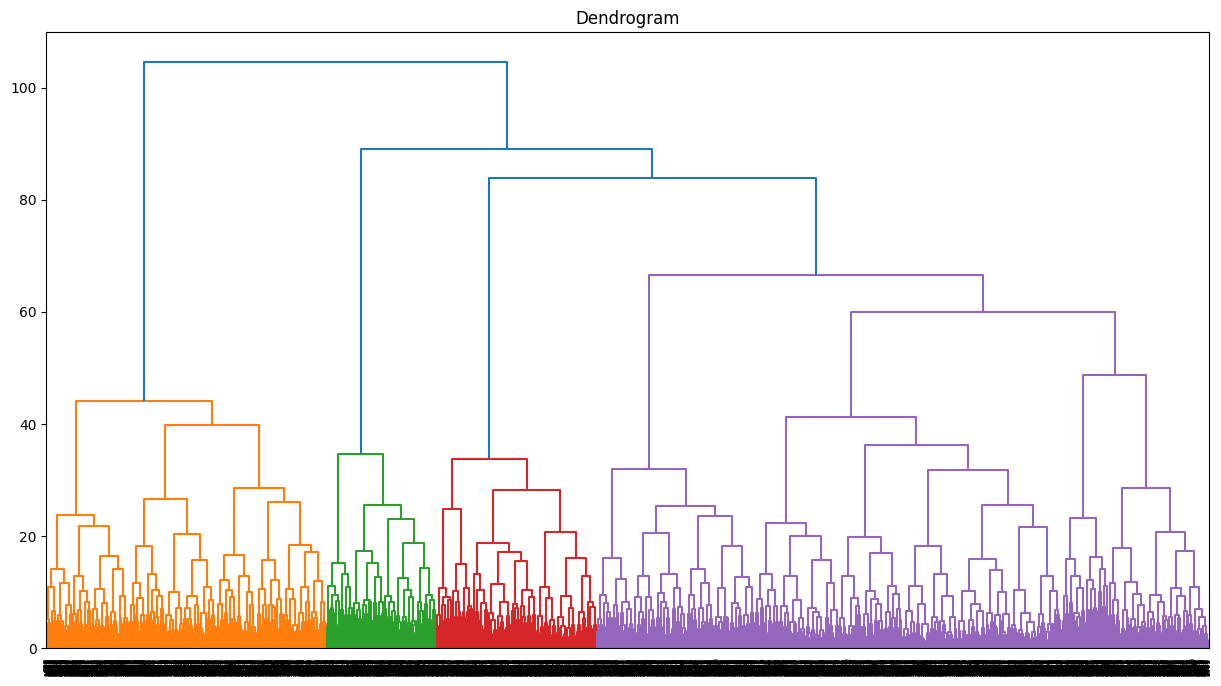

In [15]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

gym_churn['Cluster'] = clusters

In [18]:
cluster_means = gym_churn.groupby('Cluster').mean()
cluster_means

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


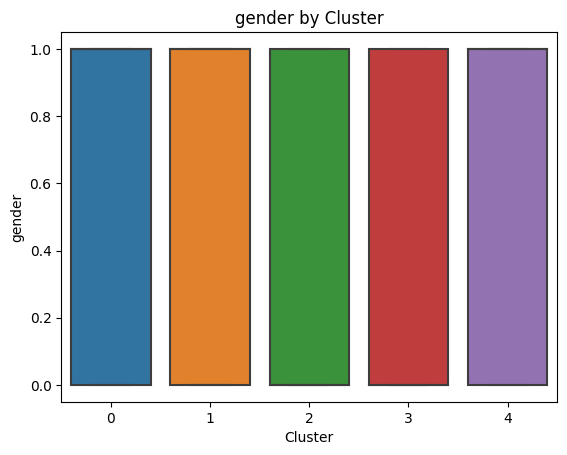

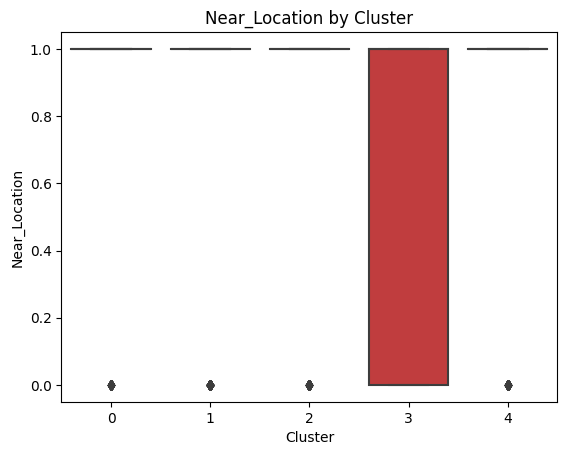

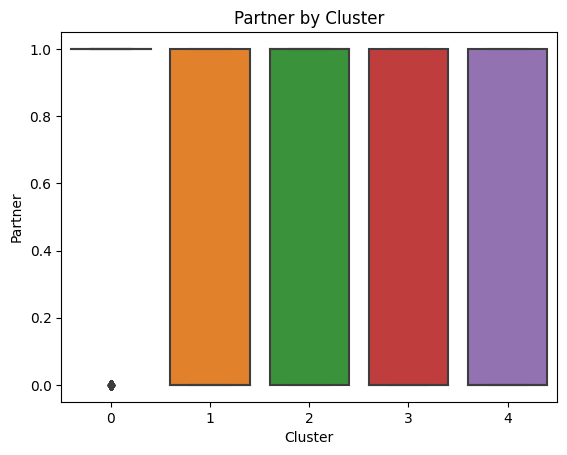

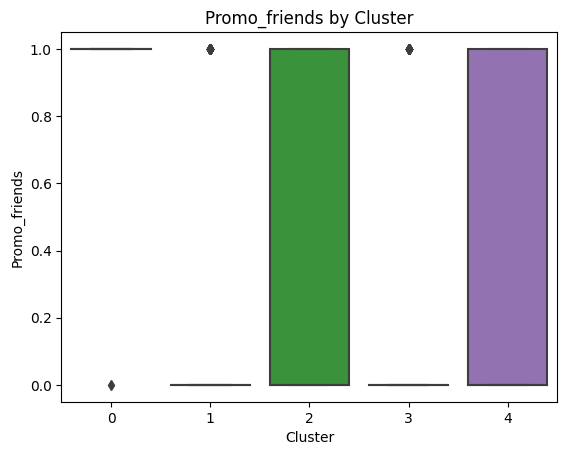

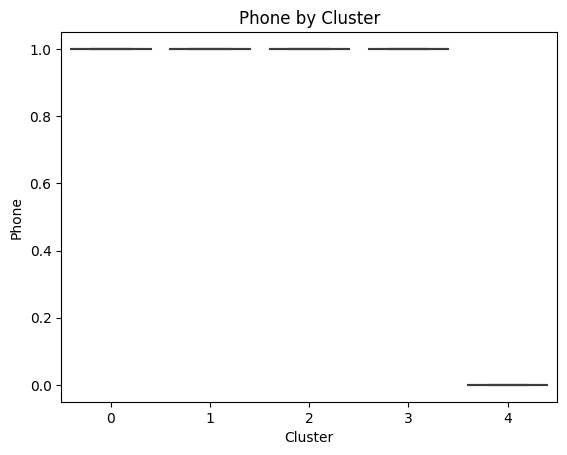

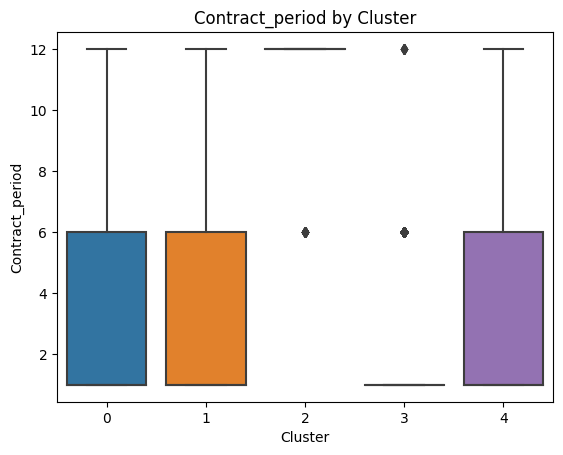

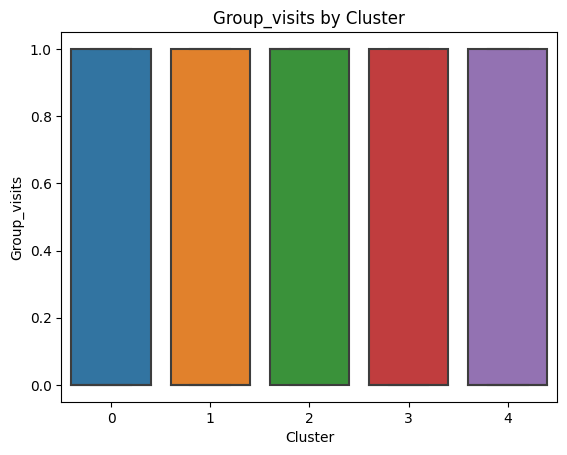

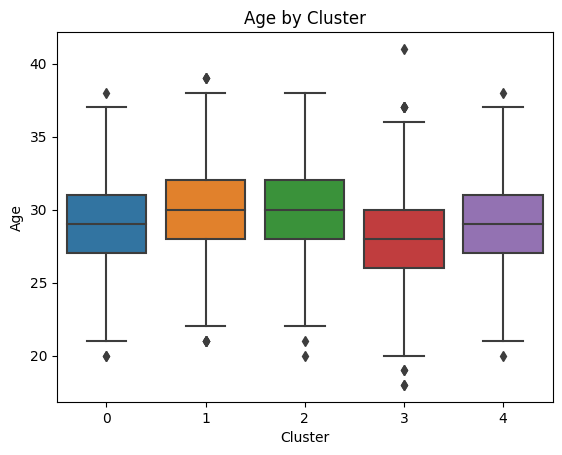

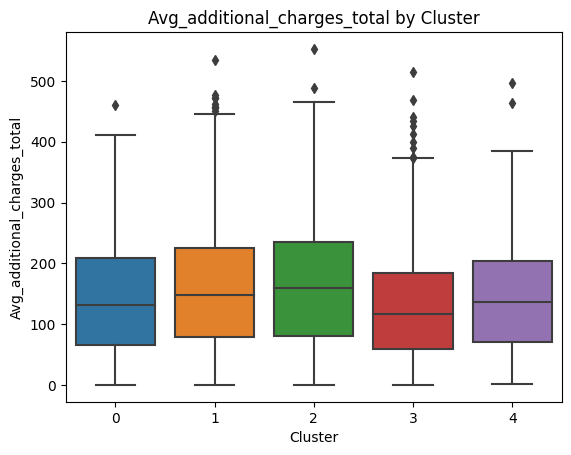

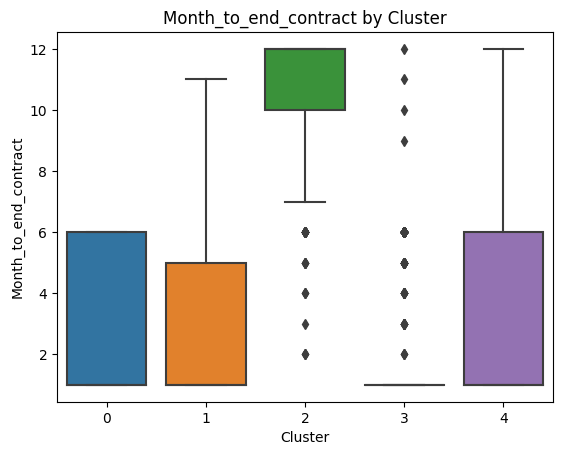

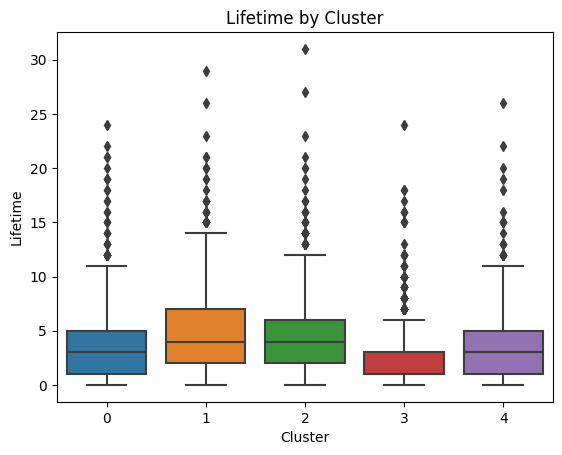

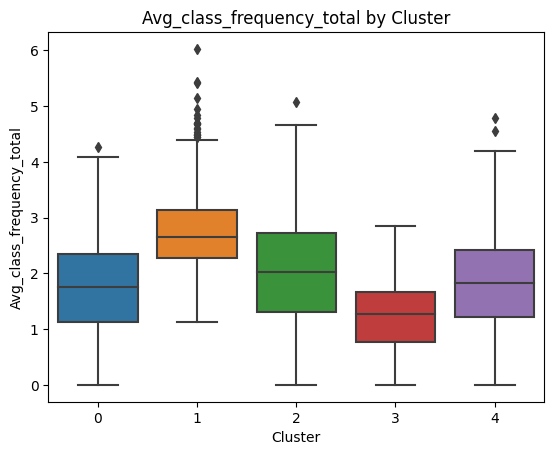

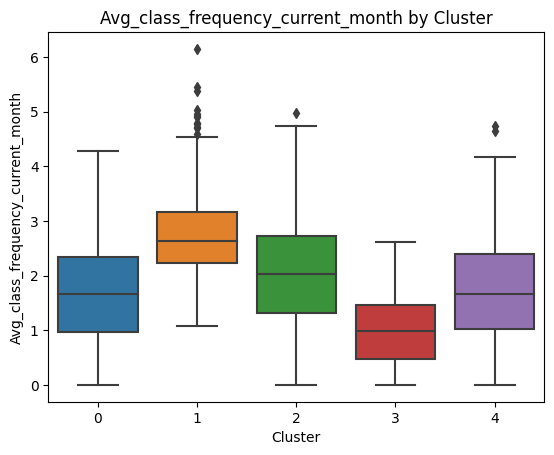

In [19]:
features = gym_churn.columns.drop(['Churn', 'Cluster'])

for col in features:
    plt.figure()
    sns.boxplot(x='Cluster', y=col, data=gym_churn)
    plt.title(f'{col} by Cluster')
    plt.show()

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Boxplot não é adequado para variáveis binárias. Um gráfico de barras seria mais adequado
</div>

In [20]:
cluster_churn = gym_churn.groupby('Cluster')['Churn'].mean()
cluster_churn

Cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

### 🔎 Análise dos Clusters

Os clusters apresentaram diferenças claras em termos de comportamento e risco de churn.

#### 🔴 Cluster 3 — Alto risco de rotatividade
Este grupo apresentou a maior taxa de churn (aproximadamente 57%).  
Os clientes desse cluster possuem características como:

- Contratos curtos
- Poucos meses restantes de contrato
- Baixo tempo de relacionamento com a academia
- Frequência de visitas reduzida, especialmente no mês atual
- Baixo nível de gastos adicionais
- Baixa participação em aulas coletivas
- Menor engajamento com programas de indicação

Esse perfil representa clientes novos e pouco engajados, sendo o principal grupo de risco.

---

#### 🟢 Cluster 2 — Clientes leais
Este grupo apresentou a menor taxa de churn (cerca de 2%).  
Principais características:

- Contratos longos
- Muitos meses restantes até o fim do contrato
- Maior tempo de permanência na academia
- Boa frequência de visitas
- Participação em aulas coletivas
- Maior consumo de serviços adicionais
- Maior engajamento com a academia

Esse cluster representa clientes altamente comprometidos e com baixo risco de saída.

---

#### 🟡 Cluster 1 — Clientes engajados
Apresentou baixa taxa de churn (aproximadamente 9%).  
Esse grupo se destaca por:

- Alta frequência de visitas
- Frequência atual elevada
- Maior tempo de permanência
- Alto consumo de serviços adicionais

Esses clientes possuem comportamento ativo e consistente.

---

#### 🟠 Clusters 0 e 4 — Risco moderado
Esses grupos apresentaram taxas intermediárias de churn (cerca de 25% a 27%).  
Embora não sejam críticos, ainda apresentam risco relevante de saída e podem se beneficiar de estratégias de retenção direcionadas.

---

### 📌 Principais Fatores Relacionados à Retenção

A análise dos agrupamentos reforçou que os fatores mais associados à permanência dos clientes são:

- Frequência de visitas, especialmente no mês atual
- Duração do contrato
- Tempo de relacionamento com a academia
- Participação em aulas coletivas
- Consumo de serviços adicionais
- Engajamento social (indicação de amigos)

## 🔹 Etapa 5 — Conclusões e Recomendações Estratégicas

Com base na análise exploratória, modelagem preditiva e segmentação de clientes, foi possível identificar padrões claros relacionados à rotatividade na Model Fitness.

A rotatividade está fortemente associada a:

- Baixa frequência de visitas, especialmente no mês atual
- Contratos de curta duração
- Pouco tempo de relacionamento com a academia
- Baixo engajamento com serviços adicionais e aulas coletivas
- Falta de vínculo social (ex.: ausência de indicação de amigos)

A seguir, são apresentados princípios estratégicos e recomendações práticas para retenção.

---

### 1️⃣ Priorizar os primeiros meses do cliente

**Conclusão:**  
Clientes novos apresentam maior probabilidade de churn, especialmente nos primeiros meses.

**Recomendações:**
- Implementar um programa de onboarding estruturado nas primeiras 4–8 semanas.
- Enviar comunicações personalizadas para novos clientes com incentivo à frequência mínima semanal.
- Oferecer avaliação física e plano de treino individual logo na adesão.
- Criar metas iniciais claras para gerar comprometimento.

---

### 2️⃣ Incentivar contratos de maior duração

**Conclusão:**  
Clientes com contratos longos apresentam taxas significativamente menores de rotatividade.

**Recomendações:**
- Oferecer descontos progressivos para contratos trimestrais, semestrais e anuais.
- Criar campanhas de upgrade de plano para clientes com bom histórico de frequência.
- Oferecer benefícios exclusivos para planos longos (ex.: aulas especiais, prioridade em agendamento).

---

### 3️⃣ Estimular engajamento e frequência

**Conclusão:**  
A frequência de visitas, especialmente no mês atual, é um dos principais indicadores de permanência.

**Recomendações:**
- Monitorar clientes com queda na frequência e enviar alertas ou incentivos personalizados.
- Criar desafios mensais de presença com recompensas simbólicas.
- Implementar notificações automáticas para clientes com mais de 7–10 dias sem comparecimento.

---

### 4️⃣ Fortalecer o vínculo social e comunitário

**Conclusão:**  
Participação em aulas coletivas e programas de indicação está associada a menor churn.

**Recomendações:**
- Incentivar aulas em grupo como estratégia de retenção.
- Reforçar campanhas de “traga um amigo”.
- Criar eventos internos e desafios coletivos para aumentar o senso de comunidade.
- Oferecer benefícios adicionais para clientes que indicarem novos membros.

---

## ✅ Considerações Finais

A análise indica que a rotatividade não ocorre de forma aleatória, mas está diretamente ligada ao nível de engajamento e ao estágio da jornada do cliente.

Uma estratégia eficaz de retenção deve:

- Identificar clientes em risco de forma antecipada (usando o modelo preditivo).
- Atuar preventivamente nos primeiros meses.
- Incentivar contratos mais longos.
- Estimular frequência e engajamento social.

A combinação de análise preditiva e ações direcionadas pode reduzir significativamente a rotatividade e aumentar o valor do ciclo de vida dos clientes.